In [1]:
import numpy as np
import glob
import os
import pandas as pd
import re

samples = ["SMC01-N", "SMC01-T", "SMC02-T", "SMC03-N", "SMC03-T", "SMC04-N", "SMC04-T", "SMC05-N", "SMC05-T", "SMC06-N", "SMC06-T",
           "SMC07-N", "SMC07-T", "SMC08-N", "SMC08-T", "SMC09-N", "SMC09-T", "SMC10-N", "SMC10-T", "SMC11-T", "SMC14-T", "SMC15-T", "SMC16-T",
           "SMC17-T", "SMC18-T", "SMC19-T", "SMC20-T", "SMC21-T", "SMC22-T", "SMC23-T", "SMC24-T", "SMC25-T"]

# pattern recognition from complex filenames to identify the names which are required for this analysis
pattern1 = "Archetype"
# pattern2 = "mellon"
# unwanted_suffix = "_dge"

combined_regex = (
    rf"(?=.*{re.escape(pattern1)})"            
    # rf"(?=.*{re.escape(pattern2)})"           
    # rf"(?!.*{re.escape(pattern2)}{re.escape(unwanted_suffix)})" 
    r".*"
)
pathway_data_all_sample = []
all_sample_files = []
for sample in samples:
    path = os.path.join("../../pipeline_testing/functional_characterization_gavish/", sample)
    search_pattern = os.path.join(path, f"*{pattern1}*")
    csv_files = glob.glob(search_pattern)
    
    csv_files_mod = []

    for file in csv_files:
        if os.path.isfile(file):
            filename = os.path.basename(file)
            if re.search(combined_regex, filename, re.IGNORECASE): 
                csv_files_mod.append(file)          
    csv_files_mod.sort()
    all_sample_files.append(csv_files_mod)
    data = []
    # Print the list of found files
    for file in csv_files_mod:
        df = pd.read_csv(file, index_col=0)
        filtered_df = df[df['Direction'] == 'Enriched in Archetype']
        print(file,filtered_df.shape)
        data.append(filtered_df)
    pathway_data_all_sample.append(data)

../../pipeline_testing/functional_characterization_gavish_test/SMC01-N/Archetype_1_specialists_mellon_high_density_specialists_and_generalists.csv (22, 5)
../../pipeline_testing/functional_characterization_gavish_test/SMC01-N/Archetype_2_0_specialists_cluster_0_mellon_high_density_specialists_and_generalists.csv (66, 5)
../../pipeline_testing/functional_characterization_gavish_test/SMC01-N/Archetype_2_1_specialists_cluster_1_mellon_high_density_specialists_and_generalists.csv (28, 5)
../../pipeline_testing/functional_characterization_gavish_test/SMC01-N/Archetype_2_2_specialists_cluster_2_mellon_high_density_specialists_and_generalists.csv (21, 5)
../../pipeline_testing/functional_characterization_gavish_test/SMC01-N/Archetype_2_3_specialists_cluster_3_mellon_high_density_specialists_and_generalists.csv (101, 5)
../../pipeline_testing/functional_characterization_gavish_test/SMC01-N/Archetype_2_4_specialists_cluster_4_mellon_high_density_specialists_and_generalists.csv (4, 5)
../../pipe

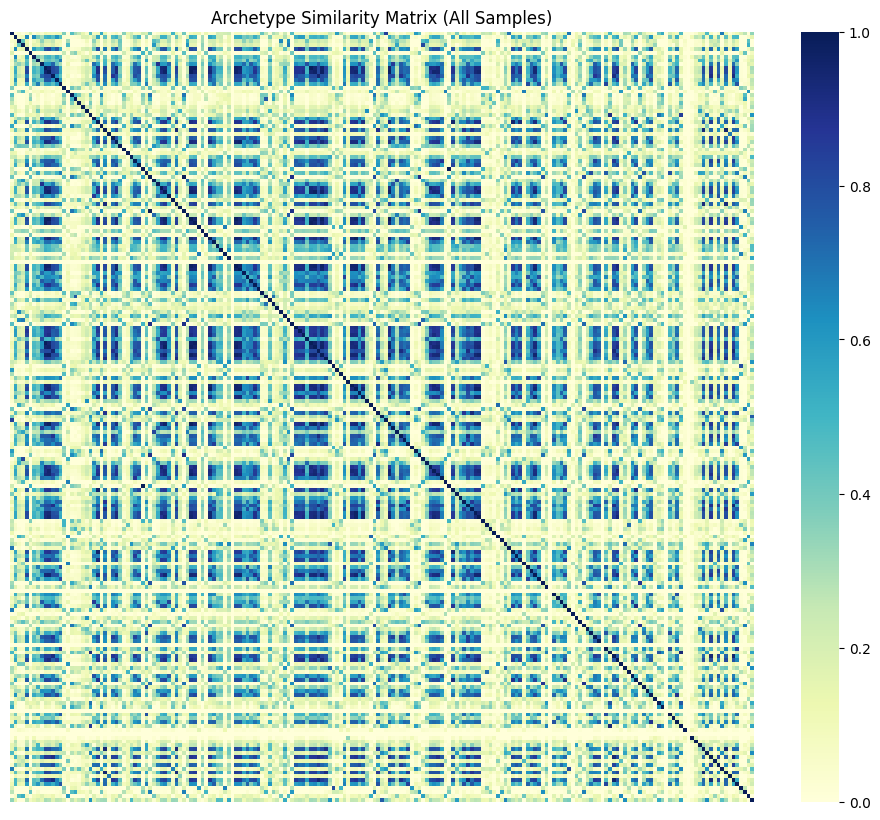

Highly Similar Pairs (>80%):
SMC01-N_A_1 and SMC09-N_A_1 are 84.6% similar
SMC01-N_A_2_2 and SMC10-N_A_2 are 81.8% similar
SMC01-N_A_2_3 and SMC01-N_A_5 are 82.1% similar
SMC01-N_A_2_3 and SMC02-T_A_2 are 80.0% similar
SMC01-N_A_2_3 and SMC05-N_A_3 are 80.8% similar
SMC01-N_A_2_3 and SMC05-T_A_3 are 80.2% similar
SMC01-N_A_2_3 and SMC06-N_A_4_5_0 are 80.0% similar
SMC01-N_A_2_3 and SMC06-N_A_4_5_1 are 81.3% similar
SMC01-N_A_2_3 and SMC07-N_A_2_3 are 86.8% similar
SMC01-N_A_2_3 and SMC07-N_A_2_4 are 82.9% similar
SMC01-N_A_2_3 and SMC07-T_A_2 are 81.5% similar
SMC01-N_A_2_3 and SMC08-N_A_6 are 81.8% similar
SMC01-N_A_2_3 and SMC08-T_A_2 are 82.4% similar
SMC01-N_A_2_3 and SMC09-N_A_2 are 82.1% similar
SMC01-N_A_2_3 and SMC11-T_A_2_1 are 81.8% similar
SMC01-N_A_2_3 and SMC11-T_A_2_2 are 80.3% similar
SMC01-N_A_2_3 and SMC15-T_A_2 are 81.3% similar
SMC01-N_A_2_3 and SMC19-T_A_2 are 80.8% similar
SMC01-N_A_3 and SMC04-N_A_3_0 are 88.9% similar
SMC01-N_A_3 and SMC09-N_A_3 are 85.7% similar

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

all_archs = []
labels = []
for s_idx, sample in enumerate(pathway_data_all_sample):
    for archetype in sample:
        all_archs.append(set(archetype.index)) 
        
    for a_idx, filename in enumerate(all_sample_files[s_idx]):
        num_archetypes = len(all_sample_files[s_idx])

        name =  os.path.basename(filename)
        parts = name.split('Archetype_')[1].split('_specialists')[0]
        arc_name = f"A_{parts}"
        labels.append(f"{samples[s_idx]}_{arc_name}")

# Calculate similarity matrix
num_archs = len(all_archs)
matrix = np.zeros((num_archs, num_archs))

for i in range(num_archs):
    for j in range(num_archs):
        set1 = all_archs[i]
        set2 = all_archs[j]
        # Calculate matching percentage
        if not set1 or not set2:
            matrix[i, j] = 0
        else:
            intersection = len(set1.intersection(set2))
            union = len(set1.union(set2))
            matrix[i, j] = intersection / union
            # matrix[i, j] = intersection / len(set1)

df_sim = pd.DataFrame(matrix, index=labels, columns=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(df_sim, cmap="YlGnBu", xticklabels=False, yticklabels=False)
plt.title("Archetype Similarity Matrix (All Samples)")
plt.show()
print("Highly Similar Pairs (>80%):")
for i in range(num_archs):
    for j in range(i + 1, num_archs): 
        if matrix[i, j] >= 0.80:
            print(f"{labels[i]} and {labels[j]} are {matrix[i, j]*100:.1f}% similar")

In [3]:
df_sim_mod = df_sim.loc[df_sim.astype(bool).any(axis=1), df_sim.astype(bool).any(axis=0)]
df_sim_mod.to_csv("../../pipeline_testing/functional_characterization_gavish/similarity_matrix_data.csv")

In [4]:
df_sim_mod.shape

(194, 194)

In [5]:
zero_rows = df_sim[(df_sim == 0).all(axis=1)]
zero_rows.to_csv('../../pipeline_testing/functional_characterization_gavish/Archetypes without any enriched functions.txt', columns=[], header=False)

/home/sbllab/.local/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/sbllab/.local/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 500x4500 with 0 Axes>

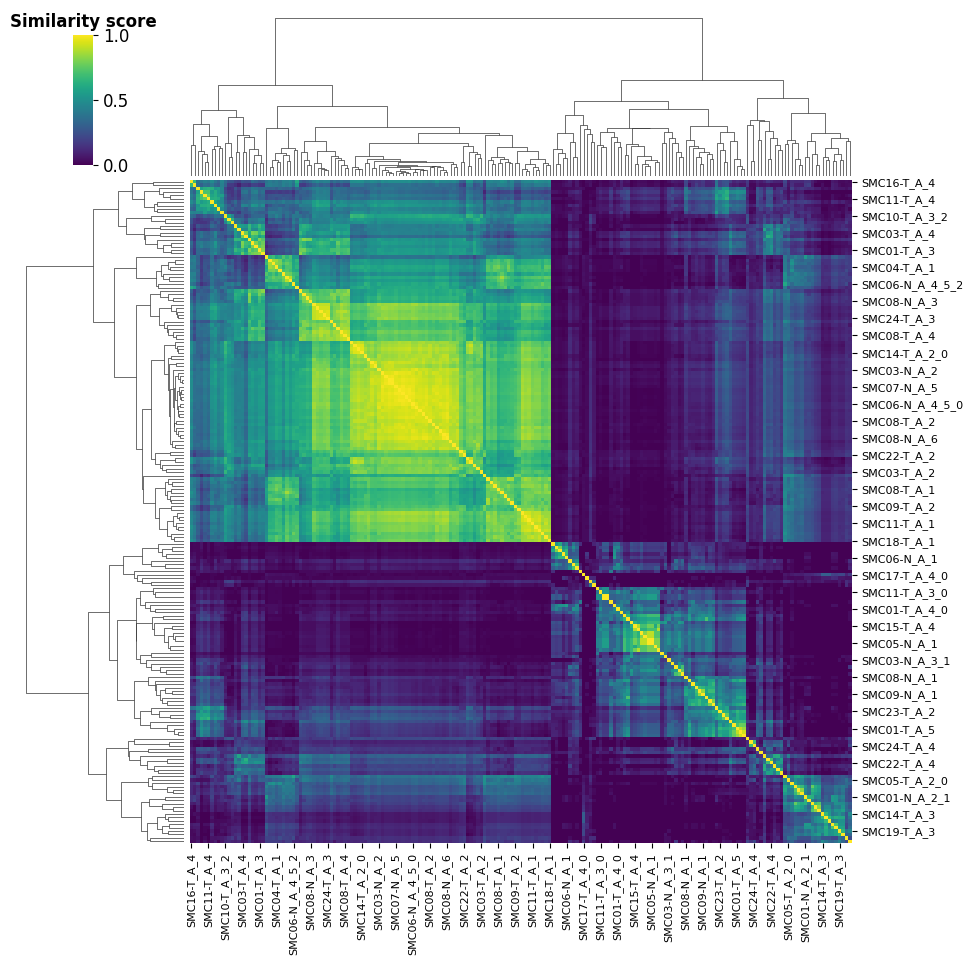

In [36]:
import matplotlib.pyplot as plt
cmap = plt.get_cmap("viridis", 256)
plt.figure(figsize=(5, 45))
g = sns.clustermap(df_sim_mod, cmap = cmap, row_cluster=True, col_cluster=True, cbar=True,  cbar_pos = (0.07, 0.83, 0.02, 0.13))
g.ax_cbar.set_title('Similarity score', fontsize=12, fontweight='bold')
g.ax_cbar.tick_params(labelsize=12)
g.ax_heatmap.tick_params(axis='x', labelsize=8)
g.ax_heatmap.tick_params(axis='y', labelsize=8) 
plt.savefig("../../pipeline_testing/functional_characterization_gavish/archetype similarity heatmap.pdf", dpi=300)
plt.show()

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Extract row and column linkage to extract clusters from the dendrograms
row_linkage = g.dendrogram_row.linkage
col_linkage = g.dendrogram_col.linkage
reordered_rows = g.dendrogram_row.reordered_ind
reordered_cols = g.dendrogram_col.reordered_ind
new_labels = df_sim_mod.index[reordered_rows].tolist()
print(f"Original order: {df_sim_mod.index.tolist()}")
print(f"Dendrogram order: {new_labels}")

Original order: ['SMC01-N_A_1', 'SMC01-N_A_2_0', 'SMC01-N_A_2_1', 'SMC01-N_A_2_2', 'SMC01-N_A_2_3', 'SMC01-N_A_2_4', 'SMC01-N_A_2_5', 'SMC01-N_A_2_6', 'SMC01-N_A_3', 'SMC01-N_A_4', 'SMC01-N_A_5', 'SMC01-T_A_1', 'SMC01-T_A_2', 'SMC01-T_A_3', 'SMC01-T_A_4_0', 'SMC01-T_A_4_1', 'SMC01-T_A_4_2', 'SMC01-T_A_4_3', 'SMC01-T_A_4_4', 'SMC01-T_A_4_5', 'SMC01-T_A_4_6', 'SMC01-T_A_5', 'SMC02-T_A_1', 'SMC02-T_A_2', 'SMC02-T_A_3', 'SMC02-T_A_4', 'SMC02-T_A_5', 'SMC03-N_A_1', 'SMC03-N_A_2', 'SMC03-N_A_3_0', 'SMC03-N_A_3_1', 'SMC03-N_A_4', 'SMC03-N_A_5', 'SMC03-T_A_1', 'SMC03-T_A_2', 'SMC03-T_A_3', 'SMC03-T_A_4', 'SMC04-N_A_1', 'SMC04-N_A_2', 'SMC04-N_A_3_0', 'SMC04-N_A_3_1', 'SMC04-N_A_4', 'SMC04-T_A_1', 'SMC04-T_A_2', 'SMC04-T_A_3', 'SMC04-T_A_4', 'SMC05-N_A_1', 'SMC05-N_A_2', 'SMC05-N_A_3', 'SMC05-N_A_4', 'SMC05-T_A_1', 'SMC05-T_A_2_0', 'SMC05-T_A_2_1', 'SMC05-T_A_3', 'SMC05-T_A_4', 'SMC05-T_A_5', 'SMC05-T_A_6', 'SMC06-N_A_1', 'SMC06-N_A_2', 'SMC06-N_A_4_5_0', 'SMC06-N_A_4_5_1', 'SMC06-N_A_4_5_2', '

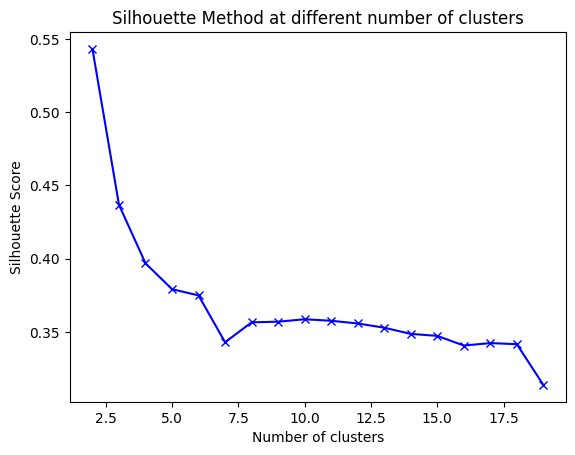

In [10]:
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster

scores = []
k_range = range(2, 20) 

# Cluster number where highest silhoutte score was observed was kept
for k in k_range:
    labels = fcluster(row_linkage, t=k, criterion='maxclust')
    score = silhouette_score(df_sim_mod, labels)
    scores.append(score)
plt.plot(k_range, scores, 'bx-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method at different number of clusters')
plt.show()

In [11]:
from scipy.cluster.hierarchy import fcluster
cluster_labels = fcluster(row_linkage, t=2, criterion='maxclust')
cluster_mapping = dict(zip(df_sim_mod.index, cluster_labels))
print("Cluster Assignments from Dendrogram:")
print(cluster_mapping)

Cluster Assignments from Dendrogram:
{'SMC01-N_A_1': np.int32(2), 'SMC01-N_A_2_0': np.int32(1), 'SMC01-N_A_2_1': np.int32(2), 'SMC01-N_A_2_2': np.int32(2), 'SMC01-N_A_2_3': np.int32(1), 'SMC01-N_A_2_4': np.int32(2), 'SMC01-N_A_2_5': np.int32(1), 'SMC01-N_A_2_6': np.int32(1), 'SMC01-N_A_3': np.int32(1), 'SMC01-N_A_4': np.int32(1), 'SMC01-N_A_5': np.int32(1), 'SMC01-T_A_1': np.int32(1), 'SMC01-T_A_2': np.int32(1), 'SMC01-T_A_3': np.int32(1), 'SMC01-T_A_4_0': np.int32(2), 'SMC01-T_A_4_1': np.int32(2), 'SMC01-T_A_4_2': np.int32(2), 'SMC01-T_A_4_3': np.int32(2), 'SMC01-T_A_4_4': np.int32(2), 'SMC01-T_A_4_5': np.int32(2), 'SMC01-T_A_4_6': np.int32(2), 'SMC01-T_A_5': np.int32(2), 'SMC02-T_A_1': np.int32(1), 'SMC02-T_A_2': np.int32(1), 'SMC02-T_A_3': np.int32(2), 'SMC02-T_A_4': np.int32(1), 'SMC02-T_A_5': np.int32(2), 'SMC03-N_A_1': np.int32(1), 'SMC03-N_A_2': np.int32(1), 'SMC03-N_A_3_0': np.int32(2), 'SMC03-N_A_3_1': np.int32(2), 'SMC03-N_A_4': np.int32(2), 'SMC03-N_A_5': np.int32(1), 'SMC03

In [12]:
df_clusters = pd.DataFrame({
    'archetype_no': df_sim_mod.index,
    'cluster': cluster_labels
})
df_clusters = df_clusters.set_index('archetype_no').loc[new_labels].reset_index()
df_clusters.to_csv("../../pipeline_testing/functional_characterization_gavish/two_big_clusters_info.csv")

In [13]:
c1 = df_clusters[df_clusters['cluster']==1]
c2 = df_clusters[df_clusters['cluster']==2]

In [14]:
c1.shape

(106, 2)

/home/sbllab/.local/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/sbllab/.local/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 500x4500 with 0 Axes>

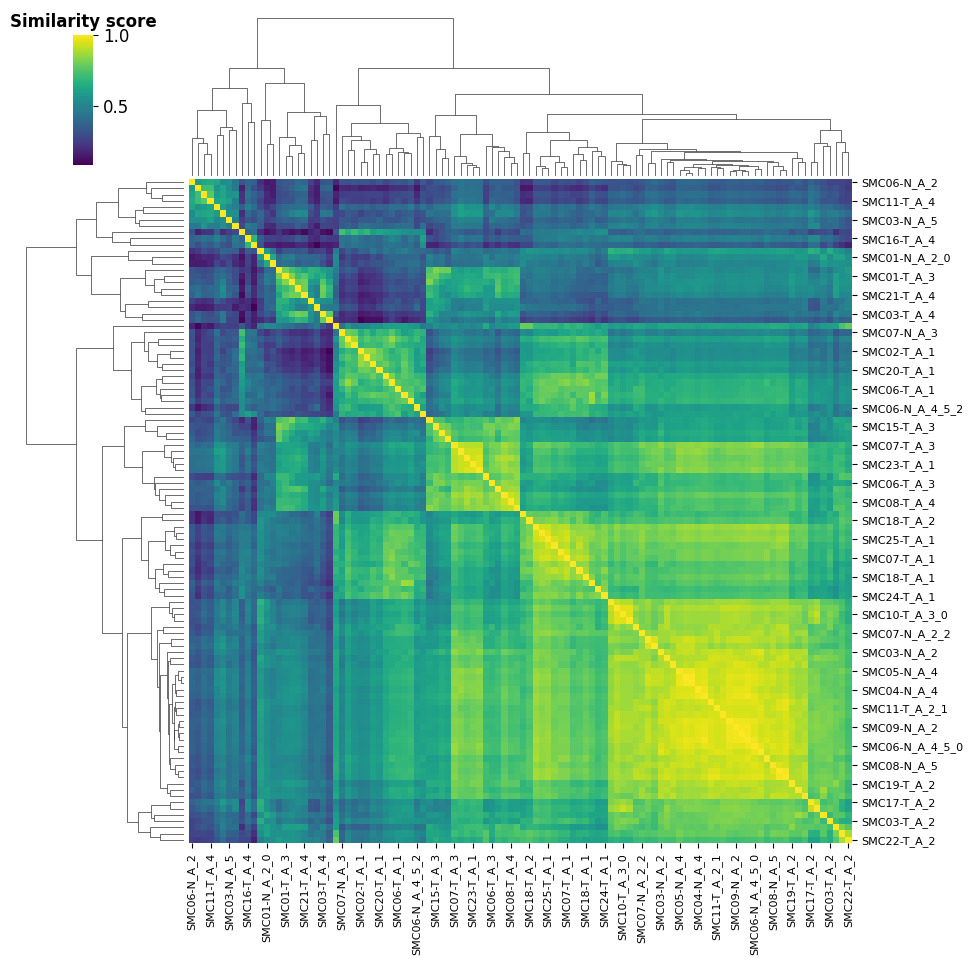

In [15]:
import matplotlib.pyplot as plt

c1_sim_df = df_sim_mod.loc[df_sim_mod.index.isin(c1.archetype_no),df_sim_mod.columns.isin(c1.archetype_no)]
cmap = plt.get_cmap("viridis", 256)
plt.figure(figsize=(5, 45))
gc1 = sns.clustermap(c1_sim_df, cmap = cmap, row_cluster=True, col_cluster=True, cbar=True,  cbar_pos = (0.07, 0.83, 0.02, 0.13))
gc1.ax_cbar.set_title('Similarity score', fontsize=12, fontweight='bold')
gc1.ax_cbar.tick_params(labelsize=12)
gc1.ax_heatmap.tick_params(axis='x', labelsize=8)
gc1.ax_heatmap.tick_params(axis='y', labelsize=8) 
plt.savefig("../../pipeline_testing/functional_characterization_gavish/archetype similarity heatmap cluster 1.pdf", dpi=300)
plt.show()

Original order: ['SMC01-N_A_2_0', 'SMC01-N_A_2_3', 'SMC01-N_A_2_5', 'SMC01-N_A_2_6', 'SMC01-N_A_3', 'SMC01-N_A_4', 'SMC01-N_A_5', 'SMC01-T_A_1', 'SMC01-T_A_2', 'SMC01-T_A_3', 'SMC02-T_A_1', 'SMC02-T_A_2', 'SMC02-T_A_4', 'SMC03-N_A_1', 'SMC03-N_A_2', 'SMC03-N_A_5', 'SMC03-T_A_1', 'SMC03-T_A_2', 'SMC03-T_A_4', 'SMC04-N_A_3_0', 'SMC04-N_A_3_1', 'SMC04-N_A_4', 'SMC04-T_A_1', 'SMC04-T_A_3', 'SMC05-N_A_3', 'SMC05-N_A_4', 'SMC05-T_A_3', 'SMC05-T_A_4', 'SMC05-T_A_5', 'SMC05-T_A_6', 'SMC06-N_A_2', 'SMC06-N_A_4_5_0', 'SMC06-N_A_4_5_1', 'SMC06-N_A_4_5_2', 'SMC06-N_A_4_5_3', 'SMC06-T_A_1', 'SMC06-T_A_2', 'SMC06-T_A_3', 'SMC06-T_A_4_2', 'SMC06-T_A_5', 'SMC07-N_A_2_2', 'SMC07-N_A_2_3', 'SMC07-N_A_2_4', 'SMC07-N_A_3', 'SMC07-N_A_4', 'SMC07-N_A_5', 'SMC07-T_A_1', 'SMC07-T_A_2', 'SMC07-T_A_3', 'SMC07-T_A_4', 'SMC08-N_A_3', 'SMC08-N_A_5', 'SMC08-N_A_6', 'SMC08-T_A_1', 'SMC08-T_A_2', 'SMC08-T_A_4', 'SMC09-N_A_2', 'SMC09-N_A_3', 'SMC09-T_A_1', 'SMC09-T_A_2', 'SMC09-T_A_3', 'SMC10-N_A_3', 'SMC10-N_A_4', 'S

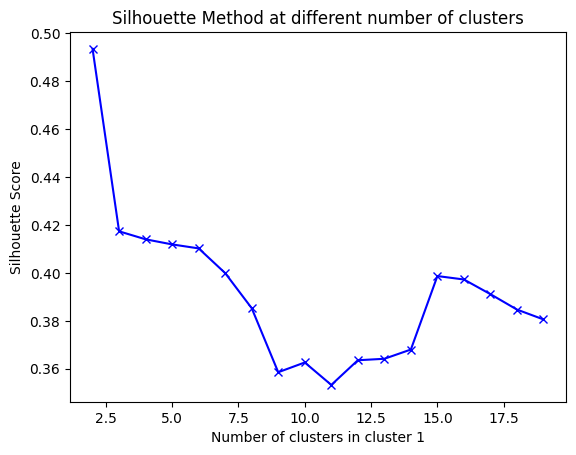

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster

row_linkage = gc1.dendrogram_row.linkage
col_linkage = gc1.dendrogram_col.linkage
reordered_rows = gc1.dendrogram_row.reordered_ind
reordered_cols = gc1.dendrogram_col.reordered_ind

new_labels_c1 = c1_sim_df.index[reordered_rows].tolist()
print(f"Original order: {c1_sim_df.index.tolist()}")
print(f"Dendrogram order: {new_labels_c1}")

scores = []
k_range = range(2, 20) 
for k in k_range:
    labels = fcluster(row_linkage, t=k, criterion='maxclust')
    score = silhouette_score(c1_sim_df, labels)
    scores.append(score)
plt.plot(k_range, scores, 'bx-')
plt.xlabel('Number of clusters in cluster 1')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method at different number of clusters')
plt.show()

In [19]:
#This is for one C1 (cluster 1). Follow same pipeline for other clusters also.
from scipy.cluster.hierarchy import fcluster

cluster_labels = fcluster(row_linkage, t=2, criterion='maxclust')
cluster_mapping = dict(zip(c1_sim_df.index, cluster_labels))
print("Cluster Assignments from Dendrogram:")
print(cluster_mapping)
df_clusters_c1 = pd.DataFrame({
    'archetype_no': c1_sim_df.index,
    'cluster': cluster_labels
})
df_clusters_c1 = df_clusters_c1.set_index('archetype_no').loc[new_labels_c1].reset_index()
df_clusters_c1.to_csv("../../pipeline_testing/functional_characterization_gavish/C1_clusters_info.csv")

Cluster Assignments from Dendrogram:
{'SMC01-N_A_2_0': np.int32(1), 'SMC01-N_A_2_3': np.int32(2), 'SMC01-N_A_2_5': np.int32(1), 'SMC01-N_A_2_6': np.int32(1), 'SMC01-N_A_3': np.int32(2), 'SMC01-N_A_4': np.int32(2), 'SMC01-N_A_5': np.int32(2), 'SMC01-T_A_1': np.int32(2), 'SMC01-T_A_2': np.int32(2), 'SMC01-T_A_3': np.int32(1), 'SMC02-T_A_1': np.int32(2), 'SMC02-T_A_2': np.int32(2), 'SMC02-T_A_4': np.int32(2), 'SMC03-N_A_1': np.int32(2), 'SMC03-N_A_2': np.int32(2), 'SMC03-N_A_5': np.int32(1), 'SMC03-T_A_1': np.int32(2), 'SMC03-T_A_2': np.int32(2), 'SMC03-T_A_4': np.int32(1), 'SMC04-N_A_3_0': np.int32(2), 'SMC04-N_A_3_1': np.int32(2), 'SMC04-N_A_4': np.int32(2), 'SMC04-T_A_1': np.int32(2), 'SMC04-T_A_3': np.int32(2), 'SMC05-N_A_3': np.int32(2), 'SMC05-N_A_4': np.int32(2), 'SMC05-T_A_3': np.int32(2), 'SMC05-T_A_4': np.int32(2), 'SMC05-T_A_5': np.int32(1), 'SMC05-T_A_6': np.int32(1), 'SMC06-N_A_2': np.int32(1), 'SMC06-N_A_4_5_0': np.int32(2), 'SMC06-N_A_4_5_1': np.int32(2), 'SMC06-N_A_4_5_2':

<Figure size 1500x6000 with 0 Axes>

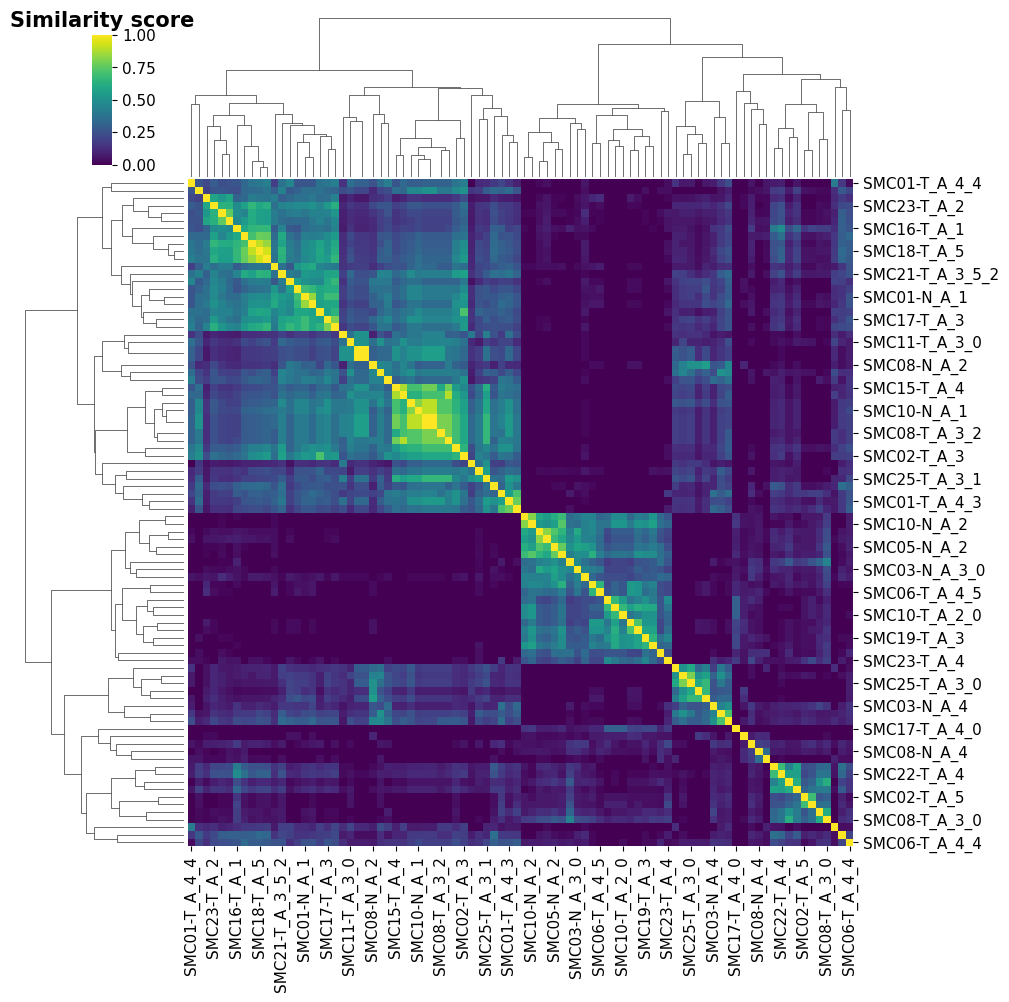

In [20]:
#This is for the another big cluster, i.e. Cluster 2

import matplotlib.pyplot as plt
c2_sim_df = df_sim_mod.loc[df_sim_mod.index.isin(c2.archetype_no),df_sim_mod.columns.isin(c2.archetype_no)]
cmap = plt.get_cmap("viridis", 256)
plt.figure(figsize=(15, 60))
gc2 = sns.clustermap(c2_sim_df, cmap = cmap, row_cluster=True, col_cluster=True, cbar=True,  cbar_pos = (0.09, 0.83, 0.02, 0.13))
gc2.ax_cbar.set_title('Similarity score', fontsize=15, fontweight='bold')
gc2.ax_cbar.tick_params(labelsize=11)
gc2.ax_heatmap.tick_params(axis='x', labelsize=11)
gc2.ax_heatmap.tick_params(axis='y', labelsize=11) 
# plt.tight_layout()
plt.savefig("../../pipeline_testing/functional_characterization_gavish/archetype similarity heatmap cluster 2.pdf", dpi=300)
plt.show()

Original order: ['SMC01-N_A_1', 'SMC01-N_A_2_1', 'SMC01-N_A_2_2', 'SMC01-N_A_2_4', 'SMC01-T_A_4_0', 'SMC01-T_A_4_1', 'SMC01-T_A_4_2', 'SMC01-T_A_4_3', 'SMC01-T_A_4_4', 'SMC01-T_A_4_5', 'SMC01-T_A_4_6', 'SMC01-T_A_5', 'SMC02-T_A_3', 'SMC02-T_A_5', 'SMC03-N_A_3_0', 'SMC03-N_A_3_1', 'SMC03-N_A_4', 'SMC03-T_A_3', 'SMC04-N_A_1', 'SMC04-N_A_2', 'SMC04-T_A_2', 'SMC04-T_A_4', 'SMC05-N_A_1', 'SMC05-N_A_2', 'SMC05-T_A_1', 'SMC05-T_A_2_0', 'SMC05-T_A_2_1', 'SMC06-N_A_1', 'SMC06-T_A_4_0', 'SMC06-T_A_4_1', 'SMC06-T_A_4_3', 'SMC06-T_A_4_4', 'SMC06-T_A_4_5', 'SMC07-N_A_2_0', 'SMC07-N_A_2_1', 'SMC07-T_A_5', 'SMC08-N_A_1', 'SMC08-N_A_2', 'SMC08-N_A_4', 'SMC08-T_A_3_0', 'SMC08-T_A_3_1', 'SMC08-T_A_3_2', 'SMC08-T_A_5', 'SMC09-N_A_1', 'SMC09-N_A_4', 'SMC09-T_A_4', 'SMC09-T_A_5', 'SMC10-N_A_1', 'SMC10-N_A_2', 'SMC10-T_A_2_0', 'SMC10-T_A_2_1', 'SMC10-T_A_3_1', 'SMC11-T_A_3_0', 'SMC11-T_A_3_1', 'SMC11-T_A_3_2', 'SMC11-T_A_3_3', 'SMC11-T_A_3_4', 'SMC11-T_A_3_5', 'SMC14-T_A_1', 'SMC14-T_A_3', 'SMC15-T_A_4', 'S

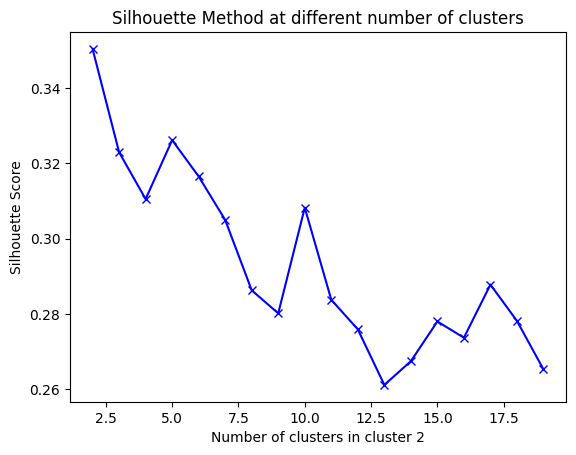

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster

row_linkage = gc2.dendrogram_row.linkage
col_linkage = gc2.dendrogram_col.linkage
reordered_rows = gc2.dendrogram_row.reordered_ind
reordered_cols = gc2.dendrogram_col.reordered_ind
new_labels_c2 = c2_sim_df.index[reordered_rows].tolist()
print(f"Original order: {c2_sim_df.index.tolist()}")
print(f"Dendrogram order: {new_labels_c2}")

scores = []
k_range = range(2, 20)
for k in k_range:
    labels = fcluster(row_linkage, t=k, criterion='maxclust')
    score = silhouette_score(c2_sim_df, labels)
    scores.append(score)
plt.plot(k_range, scores, 'bx-')
plt.xlabel('Number of clusters in cluster 2')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method at different number of clusters')
plt.show()

In [22]:
from scipy.cluster.hierarchy import fcluster
cluster_labels = fcluster(row_linkage, t=2, criterion='maxclust')
cluster_mapping = dict(zip(c2_sim_df.index, cluster_labels))
print("Cluster Assignments from Dendrogram:")
print(cluster_mapping)

df_clusters_c2 = pd.DataFrame({
    'archetype_no': c2_sim_df.index,
    'cluster': cluster_labels
})
df_clusters_c2 = df_clusters_c2.set_index('archetype_no').loc[new_labels_c2].reset_index()
df_clusters_c2.to_csv("../../pipeline_testing/functional_characterization_gavish/C2_clusters_info.csv")

Cluster Assignments from Dendrogram:
{'SMC01-N_A_1': np.int32(1), 'SMC01-N_A_2_1': np.int32(2), 'SMC01-N_A_2_2': np.int32(2), 'SMC01-N_A_2_4': np.int32(1), 'SMC01-T_A_4_0': np.int32(1), 'SMC01-T_A_4_1': np.int32(2), 'SMC01-T_A_4_2': np.int32(1), 'SMC01-T_A_4_3': np.int32(1), 'SMC01-T_A_4_4': np.int32(1), 'SMC01-T_A_4_5': np.int32(2), 'SMC01-T_A_4_6': np.int32(2), 'SMC01-T_A_5': np.int32(1), 'SMC02-T_A_3': np.int32(1), 'SMC02-T_A_5': np.int32(2), 'SMC03-N_A_3_0': np.int32(2), 'SMC03-N_A_3_1': np.int32(1), 'SMC03-N_A_4': np.int32(2), 'SMC03-T_A_3': np.int32(1), 'SMC04-N_A_1': np.int32(1), 'SMC04-N_A_2': np.int32(2), 'SMC04-T_A_2': np.int32(1), 'SMC04-T_A_4': np.int32(2), 'SMC05-N_A_1': np.int32(1), 'SMC05-N_A_2': np.int32(2), 'SMC05-T_A_1': np.int32(2), 'SMC05-T_A_2_0': np.int32(2), 'SMC05-T_A_2_1': np.int32(1), 'SMC06-N_A_1': np.int32(2), 'SMC06-T_A_4_0': np.int32(1), 'SMC06-T_A_4_1': np.int32(1), 'SMC06-T_A_4_3': np.int32(1), 'SMC06-T_A_4_4': np.int32(2), 'SMC06-T_A_4_5': np.int32(2), 

## Identifying clusters under clusters 

<Figure size 1500x6000 with 0 Axes>

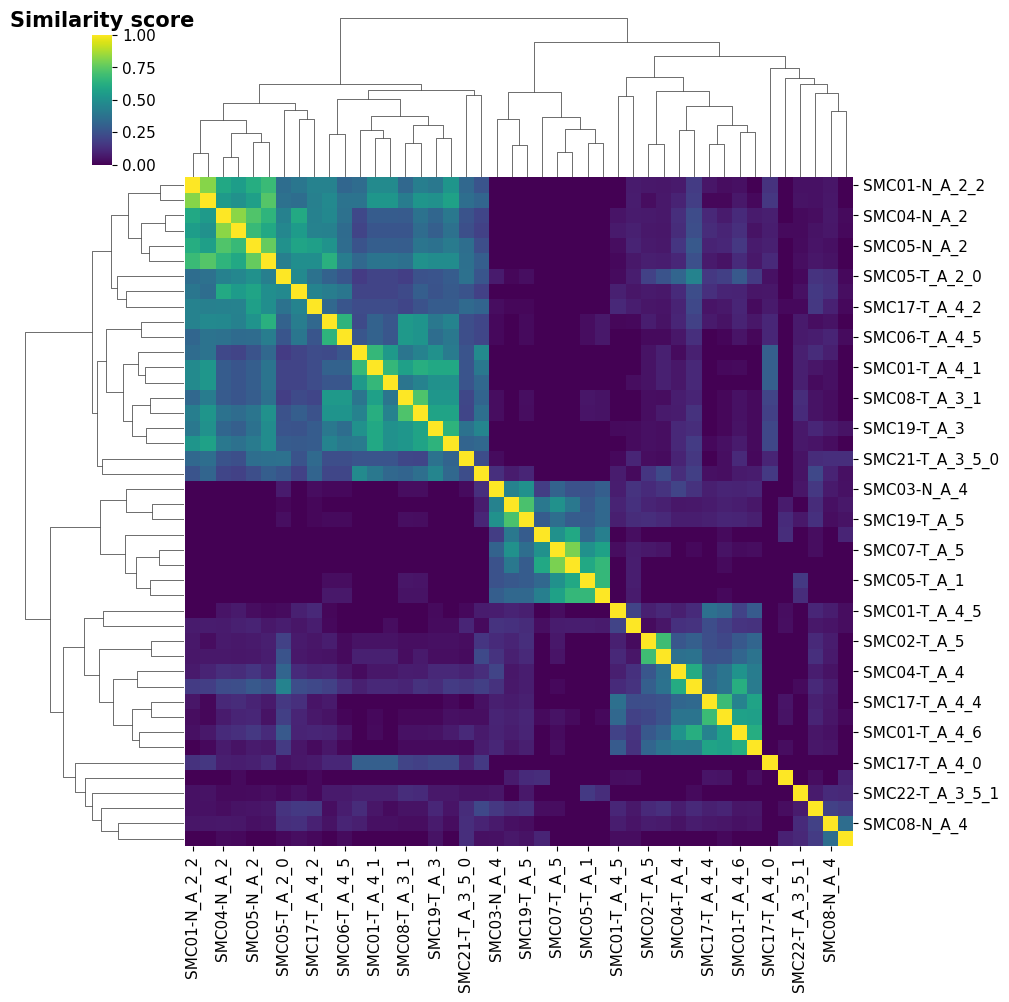

In [23]:
## This is for C2_2. Follow same pipeline for other clusters too.
c2_2 = df_clusters_c2[df_clusters_c2['cluster']==2]
c2_2_sim_df = df_sim_mod.loc[df_sim_mod.index.isin(c2_2.archetype_no),df_sim_mod.columns.isin(c2_2.archetype_no)]

import matplotlib.pyplot as plt
cmap = plt.get_cmap("viridis", 256)
plt.figure(figsize=(15, 60))
gc2_2 = sns.clustermap(c2_2_sim_df, cmap = cmap, row_cluster=True, col_cluster=True, cbar=True, cbar_pos = (0.09, 0.83, 0.02, 0.13))
gc2_2.ax_cbar.set_title('Similarity score', fontsize=15, fontweight='bold')
gc2_2.ax_cbar.tick_params(labelsize=11)
gc2_2.ax_heatmap.tick_params(axis='x', labelsize=11)
gc2_2.ax_heatmap.tick_params(axis='y', labelsize=11) 
plt.savefig("../../pipeline_testing/functional_characterization_gavish/archetype similarity heatmap cluster 2_2.pdf", dpi=300)
plt.show()

Original order: ['SMC01-N_A_2_1', 'SMC01-N_A_2_2', 'SMC01-T_A_4_1', 'SMC01-T_A_4_5', 'SMC01-T_A_4_6', 'SMC02-T_A_5', 'SMC03-N_A_3_0', 'SMC03-N_A_4', 'SMC04-N_A_2', 'SMC04-T_A_4', 'SMC05-N_A_2', 'SMC05-T_A_1', 'SMC05-T_A_2_0', 'SMC06-N_A_1', 'SMC06-T_A_4_4', 'SMC06-T_A_4_5', 'SMC07-N_A_2_0', 'SMC07-T_A_5', 'SMC08-N_A_4', 'SMC08-T_A_3_0', 'SMC08-T_A_3_1', 'SMC09-N_A_4', 'SMC09-T_A_4', 'SMC10-N_A_2', 'SMC10-T_A_2_0', 'SMC11-T_A_3_1', 'SMC11-T_A_3_3', 'SMC11-T_A_3_4', 'SMC14-T_A_3', 'SMC17-T_A_4_0', 'SMC17-T_A_4_1', 'SMC17-T_A_4_2', 'SMC17-T_A_4_4', 'SMC19-T_A_3', 'SMC19-T_A_5', 'SMC21-T_A_3_5_0', 'SMC22-T_A_3_5_1', 'SMC22-T_A_3_5_3', 'SMC22-T_A_3_5_4', 'SMC22-T_A_4', 'SMC23-T_A_4', 'SMC24-T_A_4', 'SMC25-T_A_3_0', 'SMC25-T_A_3_2']
Dendrogram order: ['SMC01-N_A_2_2', 'SMC10-N_A_2', 'SMC04-N_A_2', 'SMC09-N_A_4', 'SMC05-N_A_2', 'SMC07-N_A_2_0', 'SMC05-T_A_2_0', 'SMC03-N_A_3_0', 'SMC17-T_A_4_2', 'SMC01-N_A_2_1', 'SMC06-T_A_4_5', 'SMC14-T_A_3', 'SMC01-T_A_4_1', 'SMC10-T_A_2_0', 'SMC08-T_A_3_1',

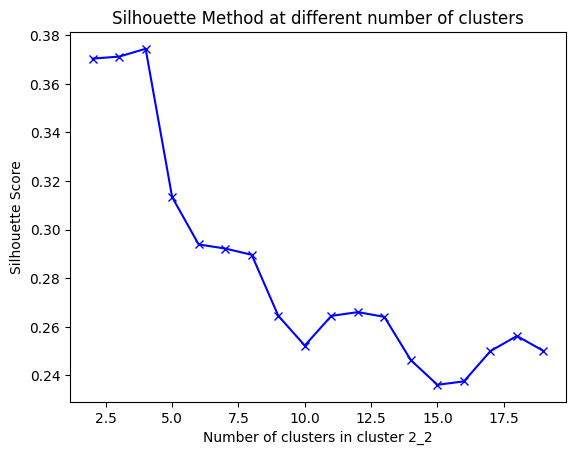

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster

row_linkage = gc2_2.dendrogram_row.linkage
col_linkage = gc2_2.dendrogram_col.linkage
reordered_rows = gc2_2.dendrogram_row.reordered_ind
reordered_cols = gc2_2.dendrogram_col.reordered_ind
new_labels_c2_2 = c2_2_sim_df.index[reordered_rows].tolist()
print(f"Original order: {c2_2_sim_df.index.tolist()}")
print(f"Dendrogram order: {new_labels_c2_2}")

scores = []
k_range = range(2, 20)

for k in k_range:
    labels = fcluster(row_linkage, t=k, criterion='maxclust')
    # Use your full symmetric matrix (df_full) for the score
    score = silhouette_score(c2_2_sim_df, labels)
    scores.append(score)
plt.plot(k_range, scores, 'bx-')
plt.xlabel('Number of clusters in cluster 2_2')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method at different number of clusters')
plt.show()

In [25]:
from scipy.cluster.hierarchy import fcluster
cluster_labels = fcluster(row_linkage, t=4, criterion='maxclust')
cluster_mapping = dict(zip(c2_2_sim_df.index, cluster_labels))
print("Cluster Assignments from Dendrogram:")
print(cluster_mapping)
df_clusters_c2_2 = pd.DataFrame({
    'archetype_no': c2_2_sim_df.index,
    'cluster': cluster_labels
})
df_clusters_c2_2 = df_clusters_c2_2.sort_values(by='cluster')
df_clusters_c2_2.to_csv("../../pipeline_testing/functional_characterization_gavish/Clusters_of_C2_2_clusters_info.csv")

Cluster Assignments from Dendrogram:
{'SMC01-N_A_2_1': np.int32(1), 'SMC01-N_A_2_2': np.int32(1), 'SMC01-T_A_4_1': np.int32(1), 'SMC01-T_A_4_5': np.int32(3), 'SMC01-T_A_4_6': np.int32(3), 'SMC02-T_A_5': np.int32(3), 'SMC03-N_A_3_0': np.int32(1), 'SMC03-N_A_4': np.int32(2), 'SMC04-N_A_2': np.int32(1), 'SMC04-T_A_4': np.int32(3), 'SMC05-N_A_2': np.int32(1), 'SMC05-T_A_1': np.int32(2), 'SMC05-T_A_2_0': np.int32(1), 'SMC06-N_A_1': np.int32(2), 'SMC06-T_A_4_4': np.int32(3), 'SMC06-T_A_4_5': np.int32(1), 'SMC07-N_A_2_0': np.int32(1), 'SMC07-T_A_5': np.int32(2), 'SMC08-N_A_4': np.int32(4), 'SMC08-T_A_3_0': np.int32(3), 'SMC08-T_A_3_1': np.int32(1), 'SMC09-N_A_4': np.int32(1), 'SMC09-T_A_4': np.int32(2), 'SMC10-N_A_2': np.int32(1), 'SMC10-T_A_2_0': np.int32(1), 'SMC11-T_A_3_1': np.int32(2), 'SMC11-T_A_3_3': np.int32(4), 'SMC11-T_A_3_4': np.int32(1), 'SMC14-T_A_3': np.int32(1), 'SMC17-T_A_4_0': np.int32(4), 'SMC17-T_A_4_1': np.int32(3), 'SMC17-T_A_4_2': np.int32(1), 'SMC17-T_A_4_4': np.int32(3)

## Check cell type compositions on archetypes that lies in a single cluster implies functional convergence

In [27]:
import pandas as pd
cons_df = pd.read_csv("../../pipeline_testing/pareto_front_consolidated_data.csv", index_col=0)
cons_df = cons_df[cons_df['archetype'] != 'Transitory_cells']
epithelial_cells = cons_df[cons_df['Cell_type']== "Epithelial cells"]
myeloid_cells = cons_df[cons_df['Cell_type']== "Myeloids"]
t_cells = cons_df[cons_df['Cell_type']== "T cells"]
stromal_cells = cons_df[cons_df['Cell_type']== "Stromal cells"]

In [28]:
print(epithelial_cells.shape)
print(myeloid_cells.shape)
print(t_cells.shape)
print(stromal_cells.shape)

(14992, 21)
(6183, 21)
(21587, 21)
(5176, 21)


In [29]:
import os
import glob

samples = ["SMC01-N", "SMC03-N", "SMC04-N", "SMC05-N", "SMC06-N", "SMC07-N", "SMC08-N", "SMC09-N", "SMC10-N",
            "SMC07-T", "SMC24-T", "SMC01-T", "SMC05-T", "SMC09-T", "SMC15-T", "SMC18-T", "SMC02-T", "SMC03-T",
            "SMC04-T", "SMC06-T", "SMC08-T", "SMC10-T", "SMC11-T", "SMC14-T", "SMC16-T", "SMC17-T", "SMC19-T",
            "SMC20-T", "SMC22-T", "SMC23-T", "SMC21-T", "SMC25-T"]

path = '../../pipeline_testing/mellon_analysis/'

def read_csvs_by_folder(parent_directory):
    folder_data_map = {}
    try:
        subfolders = [f for f in samples
                      if os.path.isdir(os.path.join(parent_directory, f))]
    except FileNotFoundError:
        print("The specified parent directory was not found.")
        return {}

    for folder in subfolders:
        files = glob.glob(os.path.join("../../pipeline_testing/mellon_analysis", folder) + "/*_specialists_and_generalists.csv")
        files.sort()
        
        # Initialize a list for the current folder
        folder_data_map[folder] = []
        
        # 2. Look for files inside the current folder
        for j,file in enumerate(files):
            file_names = [os.path.basename(file) for file in files]
            # print(file)
            
            filename = []
            for k,name in enumerate(file_names):   
                size = len(file_names)
                if k == size - 1:
                    filename.append(f"{folder}_G")
                else:
                    parts = name.split('Archetype_')[1].split('_specialists')[0]
                    name = f"{folder}_A_{parts}"
                    filename.append(name)
                
            try:
                print(file)
                df = pd.read_csv(file,index_col=0)
                df_epi = df.loc[df.cells.isin(epithelial_cells['index']),:]
                df_myo = df.loc[df.cells.isin(myeloid_cells['index']),:]
                df_t = df.loc[df.cells.isin(t_cells['index']),:]
                df_stromal = df.loc[df.cells.isin(stromal_cells['index']),:]

                per_epi = (df_epi.shape[0]/df.shape[0])*100
                per_myo = (df_myo.shape[0]/df.shape[0])*100
                per_t = (df_t.shape[0]/df.shape[0])*100
                per_stromal = (df_stromal.shape[0]/df.shape[0])*100

                per_celltype = pd.DataFrame([[per_epi, per_myo, per_t, per_stromal]], columns=['epithelial','myeloid', 'tnk', 'stromal'])
                print(per_celltype)
                
                export_path = os.path.join("../../pipeline_testing/mellon_celltype_percentage/",folder)
                print(export_path)
                # # Create nested folders, and ignore if they already exist (Python 3.2+)
                os.makedirs(export_path, exist_ok=True)
                
                per_celltype.to_csv(os.path.join(export_path,str(filename[j] + '.csv')))
               
                # Store the dataframe in the list for this folder
                folder_data_map[folder].append(df)
            except Exception as e:
                print(f"Could not read file {file}: {e}")

    return folder_data_map

parent_dir = path
sg_cells = read_csvs_by_folder(parent_dir)

../../pipeline_testing/mellon_analysis/SMC01-N/Archetype_1_specialists_mellon_high_density_specialists_and_generalists.csv
   epithelial  myeloid    tnk  stromal
0         0.0      0.0  100.0      0.0
../../pipeline_testing/mellon_celltype_percentage/SMC01-N
../../pipeline_testing/mellon_analysis/SMC01-N/Archetype_2_0_specialists_cluster_0_mellon_high_density_specialists_and_generalists.csv
   epithelial  myeloid  tnk  stromal
0         0.0      0.0  0.0    100.0
../../pipeline_testing/mellon_celltype_percentage/SMC01-N
../../pipeline_testing/mellon_analysis/SMC01-N/Archetype_2_1_specialists_cluster_1_mellon_high_density_specialists_and_generalists.csv
   epithelial  myeloid  tnk  stromal
0       100.0      0.0  0.0      0.0
../../pipeline_testing/mellon_celltype_percentage/SMC01-N
../../pipeline_testing/mellon_analysis/SMC01-N/Archetype_2_2_specialists_cluster_2_mellon_high_density_specialists_and_generalists.csv
   epithelial  myeloid  tnk    stromal
0   89.285714      0.0  0.0  10.7

In [34]:
#This is to check which are the archetypes present in a specific cluster
df_clusters_c2_1 = df_clusters_c2[df_clusters_c2['cluster']==1]
print (*df_clusters_c2_1.archetype_no)

SMC01-T_A_4_4 SMC03-N_A_3_1 SMC10-T_A_3_1 SMC23-T_A_2 SMC08-T_A_5 SMC25-T_A_4 SMC16-T_A_1 SMC21-T_A_3_5_1 SMC01-T_A_5 SMC18-T_A_5 SMC22-T_A_3_5_0 SMC08-N_A_1 SMC21-T_A_3_5_2 SMC04-T_A_2 SMC14-T_A_1 SMC01-N_A_1 SMC09-N_A_1 SMC09-T_A_5 SMC17-T_A_3 SMC24-T_A_2 SMC01-N_A_2_4 SMC11-T_A_3_0 SMC03-T_A_3 SMC10-T_A_2_1 SMC08-N_A_2 SMC01-T_A_4_0 SMC06-T_A_4_0 SMC15-T_A_4 SMC20-T_A_3 SMC07-N_A_2_1 SMC10-N_A_1 SMC04-N_A_1 SMC05-N_A_1 SMC08-T_A_3_2 SMC17-T_A_4_3 SMC01-T_A_4_2 SMC02-T_A_3 SMC05-T_A_2_1 SMC11-T_A_3_5 SMC25-T_A_3_1 SMC11-T_A_3_2 SMC06-T_A_4_3 SMC01-T_A_4_3 SMC06-T_A_4_1


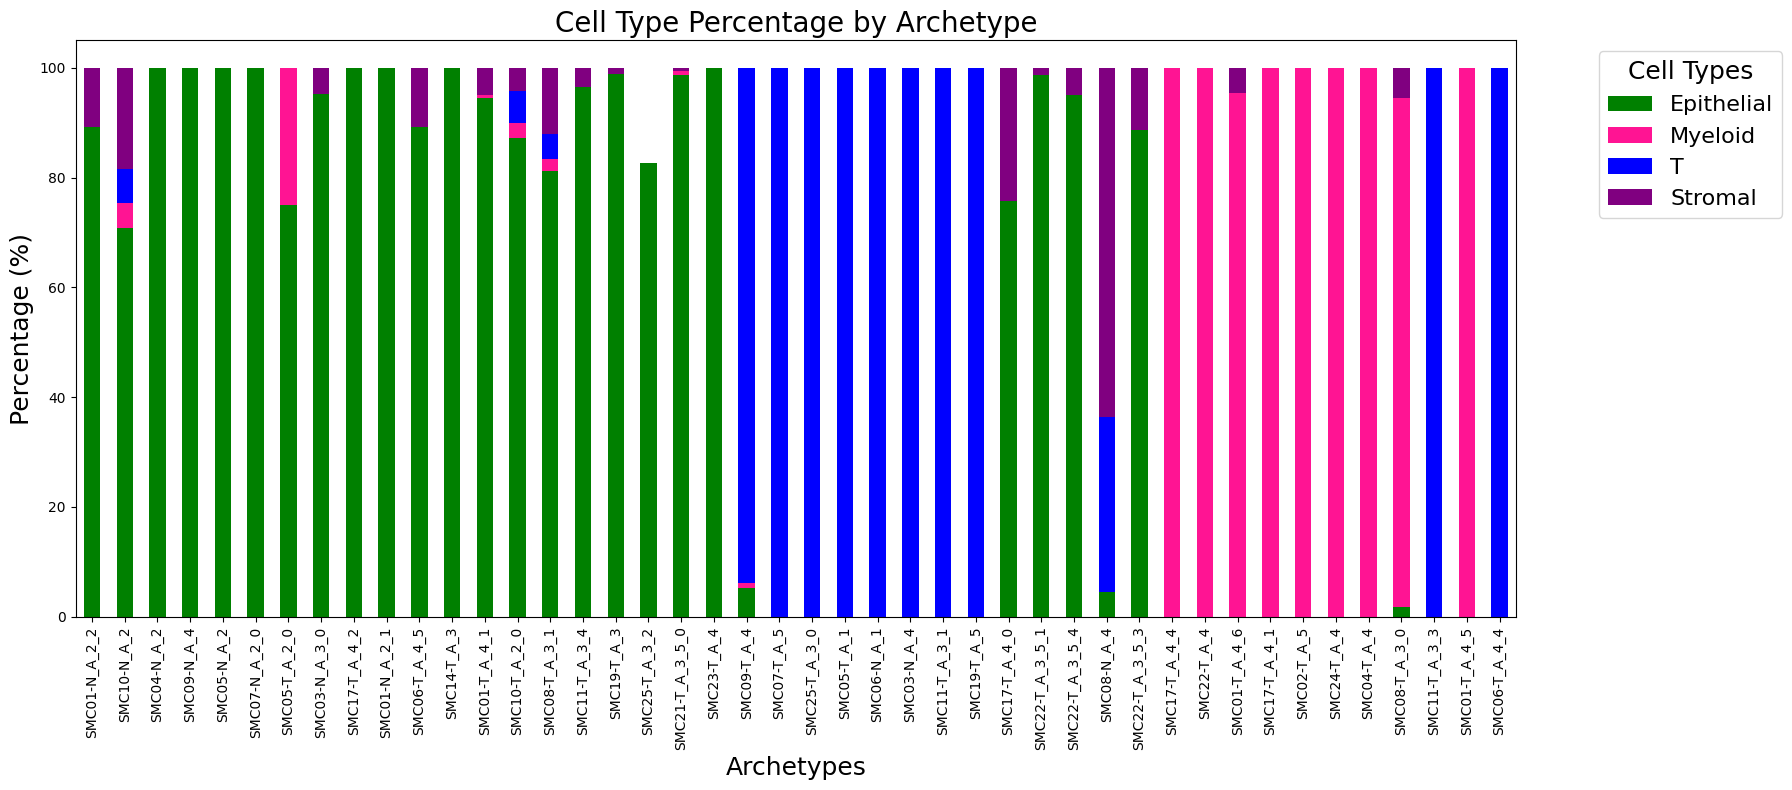

In [35]:
import os
import pandas as pd
from pathlib import Path

main_folder = Path("../../pipeline_testing/mellon_celltype_percentage")

all_dfs = []

for name in df_clusters_c2_2.archetype_no:
    folder_name = '_'.join(name.split('_')[:1])
    
    # Add the .csv extension to get the file name
    file_name = f"{name}.csv"
    
    # Construct the exact path: main_folder/folder_name/file_name
    file_path = main_folder/folder_name/file_name
    
    # Read the CSV (single row)
    df = pd.read_csv(file_path, index_col=0)
    
    raw_name = os.path.splitext(file_name)[0]
    
    # Optional: Apply your specific naming logic (from your previous question)
    # This turns "Archetype 2_2 specialists..." into "A 2_2"
    parts = raw_name.split()
    if len(parts) >= 2:
        clean_name = f"A {parts[1]}"
    else:
        clean_name = raw_name

    # Add a column for the label so we can set it as index later
    df['Sample Name'] = clean_name
    all_dfs.append(df)

# 3. Combine all single-row DataFrames into one
master_df = pd.concat(all_dfs, ignore_index=True)

# 4. Set the sample name as the index (this becomes the X-axis labels)
master_df.set_index('Sample Name', inplace=True)
master_df.columns = ['Epithelial', 'Myeloid', 'T', 'Stromal']

my_colors = {
    "T": "blue",        
    "Myeloid": "deeppink",        
    "Epithelial": "green",    
    "Stromal": "purple",   
}

color_list = [my_colors.get(col, "grey") for col in master_df.columns]

# 5. Plotting
# Assuming all other columns are the cell type percentages
ax = master_df.plot(kind='bar', stacked=True, figsize=(18, 8), color= color_list)

# Adding labels and styling
plt.title('Cell Type Percentage by Archetype', fontsize=20)
plt.xlabel('Archetypes', fontsize = 18)
plt.ylabel('Percentage (%)', fontsize=18)
plt.xticks(rotation=90) # Rotate names so they don't overlap
plt.yticks(fontsize=16)

# 2. Legend Title: Change font size here
plt.legend(title="Cell Types", fontsize=16, title_fontsize=18, bbox_to_anchor=(1.05, 1), loc='upper left')

# 3. Overall Ticks: Change size of x and y tick labels
plt.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.savefig("../../pipeline_testing/functional_characterization_gavish/cell type percentage in cluster 2_1 archetypes.pdf", dpi=300)
plt.show()